# Rama clasico sobre CIFAR-100 — CNN clasica + ConvVAE

Version para **CIFAR-100** de `XAI/Classical_CNN_CVAE.ipynb`. Mantiene la misma estructura
en seis secciones, los mismos modelos, el mismo protocolo de entrenamiento y la
misma bateria de tecnicas de explicabilidad. La unica variable que cambia
respecto al notebook de MNIST es el **contenido de las imagenes**.

Este cuaderno es el gemelo de `HQ_CNN_CVAE.ipynb`: ambos comparten pipeline de datos,
semilla, arquitectura convolucional e hiperparametros, y difieren unicamente en
la ausencia de bloque cuantico.
Cualquier diferencia observada entre los dos es por tanto atribuible al
componente cuantico y no a decisiones de diseno colaterales.

**Indice**

1. Preprocesamiento de datos y modelizacion del ruido mixto
2. Clasificacion de ruido con CNN clasica
3. Denoising con ConvVAE
4. Explicabilidad (XAI) del clasificador
5. Explicabilidad (XAI) del modelo de denoising
6. Conclusiones y guia de comparacion con el notebook gemelo

> **Por que CIFAR-100.** En MNIST cerca del 80 % de los pixeles son fondo negro
> exacto ($x = 0$), donde el speckle ($x + x\eta$) no tiene ningun efecto
> mientras que la sal-y-pimienta resulta muy visible. Eso ofrece al clasificador
> un atajo — mirar si el fondo esta limpio — que no requiere aprender las
> estadisticas del ruido. En imagenes naturales ese atajo desaparece, lo que
> convierte a CIFAR-100 en un control de validez de los resultados obtenidos
> sobre MNIST.

## 1. Preprocesamiento de datos y modelizacion del ruido mixto

### 1.1. Imports

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset, random_split

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from common_utils import (
    plot_training_curves,
    plot_confusion_matrix,
    evaluate_model,
    mostrar_reconstrucciones,
)

### 1.2. Configuracion del dataset

In [2]:
# ---------------------------------------------------------------------
# CONFIGURACION DEL DATASET
# ---------------------------------------------------------------------
# Estas constantes son el unico punto que hay que tocar para pasar de
# la variante "CIFAR nativo" a la variante "CIFAR emparejado con MNIST".
#
#   IMG_SIZE = 32  -> resolucion nativa de CIFAR-100 (variante por defecto)
#   IMG_SIZE = 28  -> se redimensiona a 28x28, de modo que TODAS las
#                     dimensiones internas coinciden exactamente con las de
#                     los notebooks de MNIST y la unica variable que cambia
#                     entre datasets es el contenido de la imagen.
#
#   GRAYSCALE = True  -> 1 canal. Recomendado: el modelo de ruido de este TFM
#                        es por pixel y esta definido sobre imagenes en escala
#                        de grises; ademas mantiene identica la arquitectura.
#   GRAYSCALE = False -> 3 canales RGB. Requiere la mascara compartida de
#                        sal-y-pimienta (ya implementada mas abajo).
#
#   NOISE_SCALE -> factor que multiplica los tres parametros de ruido.
#                  Los valores base (0.25 / 0.15 / 0.35) se ajustaron para
#                  MNIST, donde ~82 % de los pixeles son fondo negro exacto
#                  y el speckle (x + x*eta) no tiene ningun efecto sobre el.
#                  En CIFAR-100 solo ~1 % de los pixeles esta cerca de cero,
#                  asi que esos mismos valores dan SNR negativa (el ruido
#                  tiene mas potencia que la senal) y la tarea es irresoluble.
#                  Escalados medidos sobre 300 imagenes:
#                      1.0  -> SNR media -0.83 dB   (MNIST: +1.61 dB)
#                      0.6  -> SNR media +2.20 dB   equipara la dificultad
#                      0.4  -> SNR media +4.71 dB   deja mas estructura visible
# ---------------------------------------------------------------------
IMG_SIZE = 32
GRAYSCALE = True
NOISE_SCALE = 0.1

IN_CH = 1 if GRAYSCALE else 3

# Tras dos convoluciones stride=2 el mapa espacial queda en IMG_SIZE // 4.
FEAT = IMG_SIZE // 4

# Dimension aplanada del encoder del VAE (64 canales) y del clasificador (32).
ENC_FLAT = 64 * FEAT * FEAT
CLF_FLAT = 32 * FEAT * FEAT

# Parametros de ruido efectivos.
SIGMA_GAUSS   = 0.25 * NOISE_SCALE
PROB_SP       = 0.15 * NOISE_SCALE
SIGMA_SPECKLE = 0.35 * NOISE_SCALE

print(f"Imagen      : {IN_CH}x{IMG_SIZE}x{IMG_SIZE}")
print(f"Mapa conv   : {FEAT}x{FEAT}")
print(f"Flatten VAE : {ENC_FLAT}   (MNIST 28x28 -> 3136)")
print(f"Flatten CLF : {CLF_FLAT}   (MNIST 28x28 -> 1568)")
print(f"Ruido       : escala {NOISE_SCALE}  -> sigma_g={SIGMA_GAUSS:.3f} "
      f"p={PROB_SP:.3f} sigma_s={SIGMA_SPECKLE:.3f}")

Imagen      : 1x32x32
Mapa conv   : 8x8
Flatten VAE : 4096   (MNIST 28x28 -> 3136)
Flatten CLF : 2048   (MNIST 28x28 -> 1568)
Ruido       : escala 0.1  -> sigma_g=0.025 p=0.015 sigma_s=0.035


### 1.3. Reproducibilidad (semilla)

In [3]:
import random
import os
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Seed fijada: {SEED}")

Seed fijada: 42


### 1.4. Carga de CIFAR-100 y submuestreo

In [4]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

print("SSL_CERT_FILE:", os.environ["SSL_CERT_FILE"])
print("Certifi:", certifi.where())

SSL_CERT_FILE: c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\certifi\cacert.pem
Certifi: c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\certifi\cacert.pem


In [5]:
import ssl
import certifi

print(ssl.get_default_verify_paths())
print(certifi.where())

DefaultVerifyPaths(cafile='c:\\Users\\SergioHF\\Desktop\\Mi interés\\Computación Quántica\\Quanvolutional_NN_classify_reconstruct\\.venv\\Lib\\site-packages\\certifi\\cacert.pem', capath=None, openssl_cafile_env='SSL_CERT_FILE', openssl_cafile='C:\\Program Files\\Common Files\\SSL\\cert.pem', openssl_capath_env='SSL_CERT_DIR', openssl_capath='C:\\Program Files\\Common Files\\SSL\\certs')
c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\certifi\cacert.pem


In [6]:
# CIFAR-100 se convierte a escala de grises (si GRAYSCALE) y se redimensiona a
# IMG_SIZE antes de pasar a tensor en [0, 1], que es el rango que asume el
# modelo de ruido.
_tf = []
if GRAYSCALE:
    _tf.append(transforms.Grayscale(num_output_channels=1))
if IMG_SIZE != 32:
    _tf.append(transforms.Resize((IMG_SIZE, IMG_SIZE)))
_tf.append(transforms.ToTensor())

transform = transforms.Compose(_tf)

X_train_full = datasets.CIFAR100(root="./data", train=True,  download=True, transform=transform)
X_test_full  = datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)

In [7]:
n_samples_train = 400
n_samples_test = 100

# En los notebooks de MNIST el submuestreo se hacia recortando `.data` y
# `.targets`. En CIFAR-100 `.data` es un ndarray HWC y `.targets` una lista,
# asi que se usa `Subset`, que es equivalente y no depende de la version de
# torchvision. Las etiquetas originales de CIFAR (las 100 categorias) no se
# utilizan: la etiqueta de este problema es el tipo de ruido mixto.
X_train = Subset(X_train_full, range(n_samples_train))
X_test  = Subset(X_test_full,  range(n_samples_test))

In [8]:
train_size = 300
val_size = 100

split_generator = torch.Generator()
split_generator.manual_seed(SEED)

train_subset, val_subset = random_split(
    X_train,
    [train_size, val_size],
    generator=split_generator
)

### 1.5. Modelizacion del ruido mixto

Tres procesos elementales combinados por pares dan lugar a las tres clases:

- clase 0 = gaussiano + speckle
- clase 1 = gaussiano + sal y pimienta
- clase 2 = sal y pimienta + speckle

La mascara de `salt_pepper` se comparte entre canales para que el ruido
impulsivo siga siendo blanco/negro tambien en la variante RGB; con 1 canal el
comportamiento es identico al de los notebooks de MNIST.

In [9]:
def gaussian_noise(img, sigma=None, generator=None):
    sigma = SIGMA_GAUSS if sigma is None else sigma
    noise = torch.randn(img.shape, generator=generator, dtype=img.dtype) * sigma
    return torch.clamp(img + noise, 0, 1)


def salt_pepper(img, prob=None, generator=None):
    """Ruido impulsivo.

    A diferencia de la version de MNIST, la mascara se genera con forma
    (1, H, W) y se difunde sobre los canales. En una imagen RGB una mascara
    independiente por canal produciria pixeles de color aleatorio en lugar de
    impulsos blancos y negros, que es lo que el proceso fisico describe.
    Con 1 canal el comportamiento es identico al de los notebooks de MNIST.
    """
    prob = PROB_SP if prob is None else prob

    noisy = img.clone()

    mask = torch.rand(
        (1, *img.shape[1:]),
        generator=generator,
        dtype=img.dtype
    ).expand_as(img)

    noisy[mask < prob / 2] = 0
    noisy[mask > 1 - prob / 2] = 1

    return noisy


def speckle(img, sigma=None, generator=None):
    sigma = SIGMA_SPECKLE if sigma is None else sigma
    noise = torch.randn(img.shape, generator=generator, dtype=img.dtype) * sigma
    return torch.clamp(img + img * noise, 0, 1)

In [10]:
def apply_mixed_noise(img, generator):
    r = torch.randint(low=0, high=3, size=(1,), generator=generator).item()

    if r == 0:
        img = gaussian_noise(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 0
    elif r == 1:
        img = gaussian_noise(img, generator=generator)
        img = salt_pepper(img, generator=generator)
        label = 1
    else:
        img = salt_pepper(img, generator=generator)
        img = speckle(img, generator=generator)
        label = 2

    return img, label

In [11]:
def to_disp(t):
    """Convierte un tensor/array CHW en algo que `imshow` acepte.

    Devuelve HxW si la imagen tiene 1 canal y HxWx3 si tiene 3, de modo que
    las mismas celdas de visualizacion sirven para ambas variantes.
    """
    a = t.detach().cpu().numpy() if torch.is_tensor(t) else np.asarray(t)
    a = np.squeeze(a)
    if a.ndim == 3 and a.shape[0] in (1, 3):
        a = np.transpose(a, (1, 2, 0))
    return np.clip(a, 0, 1)


CMAP = "gray" if IN_CH == 1 else None

### 1.6. Datasets y DataLoaders para clasificacion

In [12]:
class NoisyCIFARDataset(Dataset):
    def __init__(self, base_dataset, seed):
        self.base = base_dataset
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.labels = []

        for img, _ in self.base:
            noisy_img, label = apply_mixed_noise(img, generator=self.generator)
            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]


train_dataset = NoisyCIFARDataset(train_subset, seed=SEED)
val_dataset   = NoisyCIFARDataset(val_subset, seed=SEED + 1)
test_dataset  = NoisyCIFARDataset(X_test, seed=SEED + 2)

In [13]:
train_generator = torch.Generator()
train_generator.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=train_generator)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch.Size([32, 1, 32, 32])
torch.Size([32])
device: cpu


### 1.7. Inspeccion visual del ruido

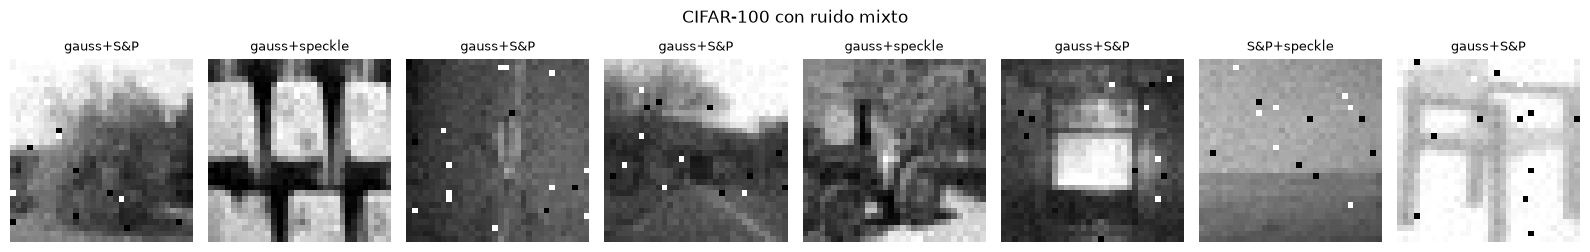

In [14]:
imgs, lbls = next(iter(train_loader))
names = {0: "gauss+speckle", 1: "gauss+S&P", 2: "S&P+speckle"}

fig, axes = plt.subplots(1, 8, figsize=(16, 2.6))
for i in range(8):
    axes[i].imshow(to_disp(imgs[i]), cmap=CMAP)
    axes[i].set_title(names[int(lbls[i])], fontsize=9)
    axes[i].axis("off")

plt.suptitle("CIFAR-100 con ruido mixto")
plt.tight_layout()
plt.show()

## 2. Clasificacion de ruido con CNN clasica

### 2.1. Arquitectura de la red

Extractor convolucional identico al del modelo hibrido y mismo cuello de botella
de dimension 4 acotado a $[-\pi, \pi]$. El circuito variacional se sustituye por
un `feature_mixer` clasico con la misma entrada y la misma salida (3 logits).

In [15]:
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(IN_CH, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(CLF_FLAT, 128)
        self.fc2 = nn.Linear(128, 4)

        # Bloque clasico que sustituye a la QNN del modelo hibrido: mismo punto
        # de entrada (vector 4D acotado a [-pi, pi]) y misma salida (3 logits).
        self.feature_mixer = nn.Sequential(
            nn.Linear(4, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, 3),
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # .reshape() en vez de .view(): LIME genera tensores no contiguos.
        x = x.reshape(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x)) * np.pi

        x = self.feature_mixer(x)
        return x


model_clf = ClassicalNet().to(device)
model_clf

ClassicalNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
  (feature_mixer): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): Tanh()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)

### 2.3. Entrenamiento

In [16]:
optimizer_clf = optim.AdamW(model_clf.parameters(), lr=1e-3)
criterion_clf = nn.CrossEntropyLoss()

epochs = 10
train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

start_time = time.time()
patience = 3
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):

    model_clf.train()
    total_loss, correct, total = 0, 0, 0

    for data, target in train_loader:
        data, target = data.to(device), target.to(device)

        optimizer_clf.zero_grad()
        output = model_clf(data)
        loss = criterion_clf(output, target)
        loss.backward()
        optimizer_clf.step()

        total_loss += loss.item() * data.size(0)
        _, predicted = torch.max(output, 1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    avg_train_loss = total_loss / total
    train_acc = correct / total
    train_loss_list.append(avg_train_loss)
    train_acc_list.append(train_acc)

    model_clf.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model_clf(data)
            loss = criterion_clf(output, target)
            val_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output, 1)
            correct += (predicted == target).sum().item()
            total += target.size(0)

    avg_val_loss = val_loss / total
    val_acc = correct / total
    val_loss_list.append(avg_val_loss)
    val_acc_list.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model_clf.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

training_time = time.time() - start_time
model_clf.load_state_dict(best_model_state)

print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")

Epoch 1/10 | Train Loss: 1.1020 | Train Acc: 0.3200 | Val Loss: 1.1166 | Val Acc: 0.3600
Epoch 2/10 | Train Loss: 1.0980 | Train Acc: 0.3733 | Val Loss: 1.1169 | Val Acc: 0.3600
Epoch 3/10 | Train Loss: 1.0979 | Train Acc: 0.3733 | Val Loss: 1.1032 | Val Acc: 0.3600
Epoch 4/10 | Train Loss: 1.0955 | Train Acc: 0.3733 | Val Loss: 1.0974 | Val Acc: 0.3600
Epoch 5/10 | Train Loss: 1.0945 | Train Acc: 0.3733 | Val Loss: 1.1055 | Val Acc: 0.3600
Epoch 6/10 | Train Loss: 1.0932 | Train Acc: 0.3733 | Val Loss: 1.1018 | Val Acc: 0.3600
Epoch 7/10 | Train Loss: 1.0910 | Train Acc: 0.3733 | Val Loss: 1.0960 | Val Acc: 0.3600
Epoch 8/10 | Train Loss: 1.0860 | Train Acc: 0.3733 | Val Loss: 1.0837 | Val Acc: 0.3600
Epoch 9/10 | Train Loss: 1.0734 | Train Acc: 0.3933 | Val Loss: 1.0610 | Val Acc: 0.5600
Epoch 10/10 | Train Loss: 1.0779 | Train Acc: 0.4200 | Val Loss: 1.0719 | Val Acc: 0.4400
Tiempo de entrenamiento: 1.02 segundos
Tiempo en minutos y segundos: 0 minutos y 1 segundos


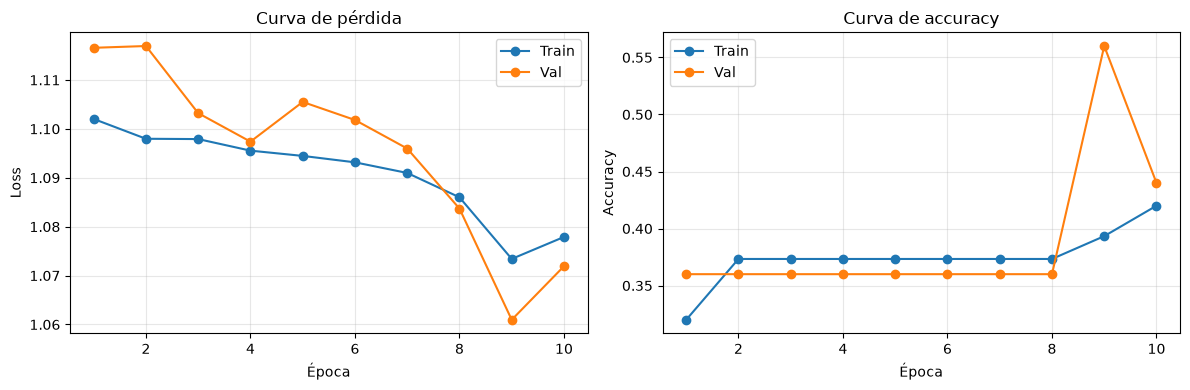

In [17]:
plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

### 2.4. Evaluacion en test y matriz de confusion

Accuracy: 0.35
                     precision    recall  f1-score   support

   gaussian+speckle       1.00      0.09      0.17        33
gaussian+saltpepper       0.33      0.94      0.49        33
 saltpepper+speckle       0.25      0.03      0.05        34

           accuracy                           0.35       100
          macro avg       0.53      0.35      0.24       100
       weighted avg       0.53      0.35      0.24       100



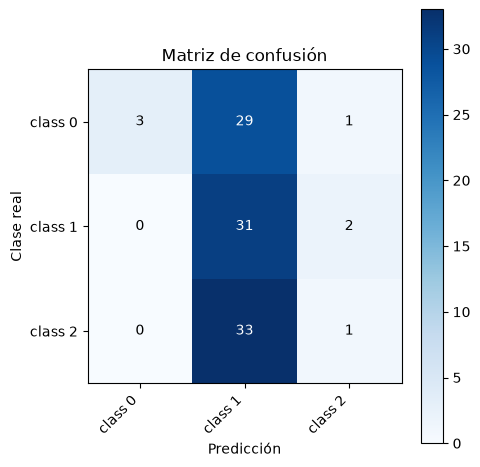

In [18]:
results_clf = evaluate_model(model_clf, test_loader, device)

print("Accuracy:", results_clf["accuracy"])
print(results_clf["report"])

plot_confusion_matrix(
    results_clf["confusion_matrix"],
    ["class 0", "class 1", "class 2"]
)

Compara esta accuracy con la del notebook gemelo `HQ_CNN_CVAE.ipynb` y, sobre todo,
con la obtenida por este mismo modelo sobre MNIST. Una caida sustancial en
CIFAR-100 seria coherente con la hipotesis de que parte del rendimiento en MNIST
proviene del atajo del fondo negro descrito en la cabecera.

## 3. Denoising de imagenes con ConvVAE

### 3.1. Dataset de denoising

In [19]:
class DenoisingCIFARDataset(Dataset):
    def __init__(self, base_dataset, seed):
        self.base = base_dataset
        self.generator = torch.Generator()
        self.generator.manual_seed(seed)

        self.noisy_images = []
        self.clean_images = []

        for img, _ in self.base:
            noisy_img, _ = apply_mixed_noise(img, generator=self.generator)
            self.clean_images.append(img)
            self.noisy_images.append(noisy_img)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.clean_images[idx]


train_dataset_dn = DenoisingCIFARDataset(train_subset, seed=SEED)
val_dataset_dn   = DenoisingCIFARDataset(val_subset, seed=SEED + 1)
test_dataset_dn  = DenoisingCIFARDataset(X_test, seed=SEED + 2)

train_generator_dn = torch.Generator()
train_generator_dn.manual_seed(SEED)

train_loader_dn = DataLoader(train_dataset_dn, batch_size=16, shuffle=True, generator=train_generator_dn)
val_loader_dn   = DataLoader(val_dataset_dn, batch_size=16, shuffle=False)
test_loader_dn  = DataLoader(test_dataset_dn, batch_size=16, shuffle=False)

### 3.2. Funcion de perdida ($\beta$-VAE)

In [20]:
def vae_loss(recon_x, x, mu, logvar, beta=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = bce + beta * kl
    return total, bce, kl

### 3.3. Arquitectura del ConvVAE clasico

Encoder y decoder identicos a los del modelo hibrido. El bloque cuantico se
sustituye por un `latent_transform` clasico con la misma dimension de salida
(`N_OBS = 6`), de modo que `fc_decode` recibe un vector del mismo tamano en
ambas ramas.

In [21]:
N_OBS = 6  # n de observables del bloque cuantico del modelo hibrido (ver
           # HQ_CNN_CVAE.ipynb); se conserva la misma dimension en la rama
           # clasica unicamente para que ambas sean comparables 1 a 1.


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=12):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(IN_CH, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        self.fc_mu = nn.Linear(ENC_FLAT, latent_dim)
        self.fc_logvar = nn.Linear(ENC_FLAT, latent_dim)

        self.latent_transform = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, N_OBS),
        )

        self.fc_decode = nn.Linear(latent_dim + N_OBS, ENC_FLAT)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, FEAT, FEAT)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, IN_CH, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5 * logvar)
        return mu + sigma * torch.randn_like(sigma)

    def decode(self, z):
        z_classical = self.latent_transform(z)
        z_combined = torch.cat([z, z_classical], dim=1)
        return self.decoder(self.fc_decode(z_combined))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

    def reconstruct(self, x):
        mu, logvar = self.encode(x)
        return self.decode(mu)


model_vae = ConvVAE(latent_dim=12).to(device)
model_vae

ConvVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=4096, out_features=12, bias=True)
  (fc_logvar): Linear(in_features=4096, out_features=12, bias=True)
  (latent_transform): Sequential(
    (0): Linear(in_features=12, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=6, bias=True)
  )
  (fc_decode): Linear(in_features=18, out_features=4096, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 8, 8))
    (1): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Sigmoid()
  )
)

### 3.5. Entrenamiento

In [22]:
optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

EPOCHS = 100

vae_train_loss, vae_val_loss = [], []
vae_train_bce, vae_val_bce = [], []
vae_train_kl, vae_val_kl = [], []

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    model_vae.train()
    train_loss = train_bce = train_kl = 0
    n_train = 0

    for noisy, clean in train_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer_vae.zero_grad()
        recon, mu, logvar = model_vae(noisy)
        loss, bce, kl = vae_loss(recon, clean, mu, logvar)
        loss.backward()
        optimizer_vae.step()

        bs = noisy.size(0)
        train_loss += loss.item() * bs
        train_bce += bce.item() * bs
        train_kl += kl.item() * bs
        n_train += bs

    train_loss /= n_train
    train_bce /= n_train
    train_kl /= n_train

    model_vae.eval()
    val_loss = val_bce = val_kl = 0
    n_val = 0

    with torch.no_grad():
        for noisy, clean in val_loader_dn:
            noisy, clean = noisy.to(device), clean.to(device)
            recon, mu, logvar = model_vae(noisy)
            loss, bce, kl = vae_loss(recon, clean, mu, logvar)

            bs = noisy.size(0)
            val_loss += loss.item() * bs
            val_bce += bce.item() * bs
            val_kl += kl.item() * bs
            n_val += bs

    val_loss /= n_val
    val_bce /= n_val
    val_kl /= n_val

    vae_train_loss.append(train_loss); vae_val_loss.append(val_loss)
    vae_train_bce.append(train_bce); vae_val_bce.append(val_bce)
    vae_train_kl.append(train_kl); vae_val_kl.append(val_kl)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train BCE: {train_bce:.4f} | Val BCE: {val_bce:.4f} | "
        f"Train KL: {train_kl:.4f} | Val KL: {val_kl:.4f}"
    )

training_time = time.time() - start_time
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo en minutos y segundos: {int(training_time // 60)} minutos y {int(training_time % 60)} segundos")

Epoch 01/100 | Train Loss: 711.7257 | Val Loss: 710.6314 | Train BCE: 711.1423 | Val BCE: 710.2937 | Train KL: 1.1668 | Val KL: 0.6755
Epoch 02/100 | Train Loss: 704.0647 | Val Loss: 697.3816 | Train BCE: 702.7049 | Val BCE: 693.6778 | Train KL: 2.7196 | Val KL: 7.4077
Epoch 03/100 | Train Loss: 677.3800 | Val Loss: 673.8913 | Train BCE: 670.6599 | Val BCE: 668.5343 | Train KL: 13.4402 | Val KL: 10.7141
Epoch 04/100 | Train Loss: 653.9881 | Val Loss: 659.8788 | Train BCE: 647.7268 | Val BCE: 653.3236 | Train KL: 12.5227 | Val KL: 13.1104
Epoch 05/100 | Train Loss: 643.5878 | Val Loss: 655.7196 | Train BCE: 636.1127 | Val BCE: 648.4729 | Train KL: 14.9502 | Val KL: 14.4935
Epoch 06/100 | Train Loss: 637.7122 | Val Loss: 652.3675 | Train BCE: 630.5050 | Val BCE: 644.9549 | Train KL: 14.4144 | Val KL: 14.8252
Epoch 07/100 | Train Loss: 634.0827 | Val Loss: 650.8047 | Train BCE: 626.2581 | Val BCE: 643.6320 | Train KL: 15.6493 | Val KL: 14.3454
Epoch 08/100 | Train Loss: 631.1163 | Val Los

### 3.6. Reconstrucciones y metricas cuantitativas

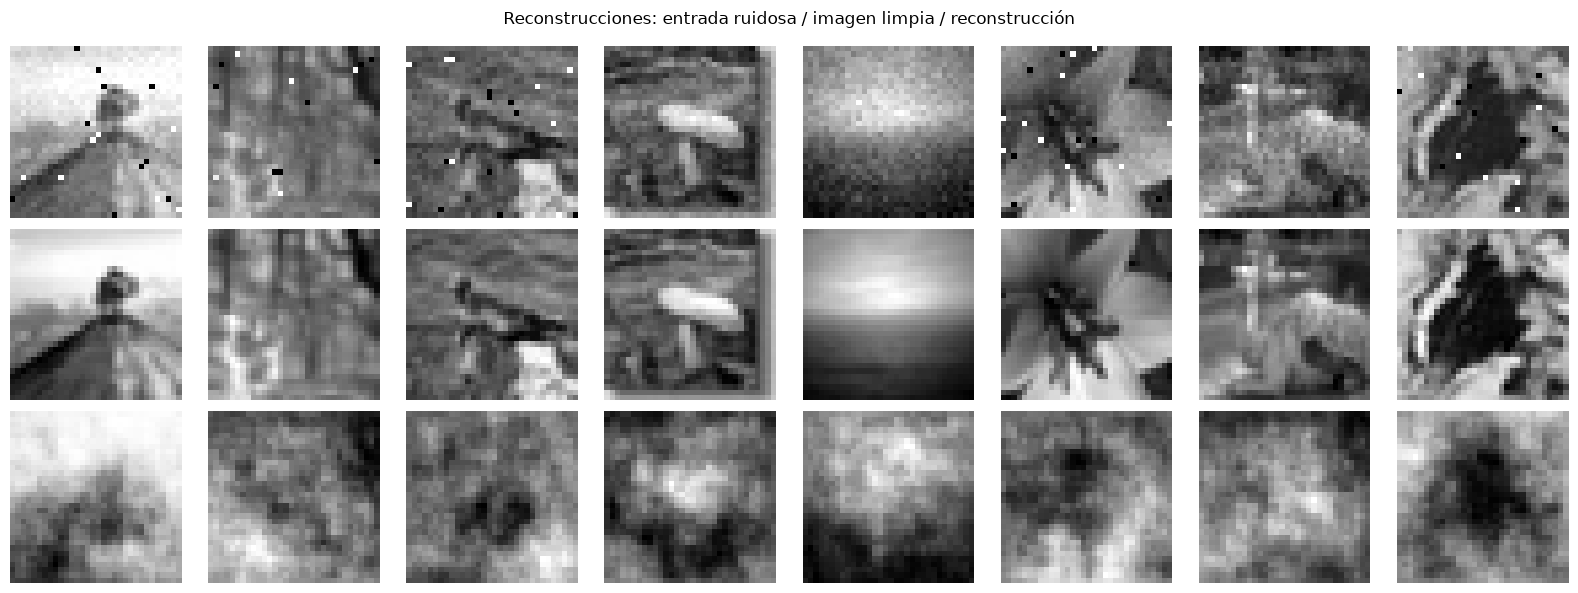

In [23]:
mostrar_reconstrucciones(model_vae, test_dataset_dn, n=8, device=device)

In [24]:
from sklearn.metrics import mean_squared_error


def evaluate_vae(model, dataset, device):
    model.eval()
    mse_list, psnr_list = [], []

    with torch.no_grad():
        for noisy, clean in DataLoader(dataset, batch_size=32, shuffle=False):
            noisy, clean = noisy.to(device), clean.to(device)
            recon = model.reconstruct(noisy)

            mse = F.mse_loss(recon, clean, reduction='none')
            mse = mse.view(mse.size(0), -1).mean(dim=1)
            mse_list.extend(mse.cpu().numpy())

            psnr = 10 * np.log10(1.0 / (mse.cpu().numpy() + 1e-10))
            psnr_list.extend(psnr)

    return {"MSE": np.mean(mse_list), "PSNR": np.mean(psnr_list)}

In [25]:
from skimage.metrics import structural_similarity as ssim


def ssim_dataset(model, loader, device):
    """SSIM medio sobre el loader. `channel_axis` se activa solo en RGB."""
    model.eval()
    vals = []

    with torch.no_grad():
        for noisy, clean in loader:
            noisy, clean = noisy.to(device), clean.to(device)
            recon = model.reconstruct(noisy)

            recon_np = recon.cpu().numpy()
            clean_np = clean.cpu().numpy()

            for i in range(recon_np.shape[0]):
                r, c = recon_np[i], clean_np[i]
                if IN_CH == 1:
                    vals.append(ssim(c[0], r[0], data_range=1.0))
                else:
                    vals.append(
                        ssim(
                            np.transpose(c, (1, 2, 0)),
                            np.transpose(r, (1, 2, 0)),
                            data_range=1.0,
                            channel_axis=-1,
                        )
                    )

    return float(np.mean(vals))

In [26]:
vae_results = evaluate_vae(model_vae, test_dataset_dn, device)
vae_ssim = ssim_dataset(model_vae, test_loader_dn, device)

print("ConvVAE sobre CIFAR-100:")
print("  MSE :", round(float(vae_results["MSE"]), 6))
print("  PSNR:", round(float(vae_results["PSNR"]), 4), "dB")
print("  SSIM:", round(vae_ssim, 4))

ConvVAE sobre CIFAR-100:
  MSE : 0.023662
  PSNR: 16.9919 dB
  SSIM: 0.2863


## 4. Explicabilidad (XAI) del clasificador (CNN clasica)

Se aplica la misma bateria de tecnicas que en `HQ_CNN_CVAE.ipynb` sobre `model_clf`,
de modo que las figuras de ambos notebooks sean directamente superponibles.

In [27]:
from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    LayerGradCam,
    LayerAttribution,
)

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 4.1. Visualizacion de activaciones internas (`conv1`, `conv2`)

In [28]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

hook1 = model_clf.conv1.register_forward_hook(get_activation('conv1'))
hook2 = model_clf.conv2.register_forward_hook(get_activation('conv2'))

In [29]:
model_clf.eval()

images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

with torch.no_grad():
    pred = model_clf(image).argmax(dim=1).item()

print(f"Clase real: {label}")
print(f"Clase predicha: {pred}")

_ = model_clf(image)  # forward pass para poblar `activations`

Clase real: 1
Clase predicha: 1


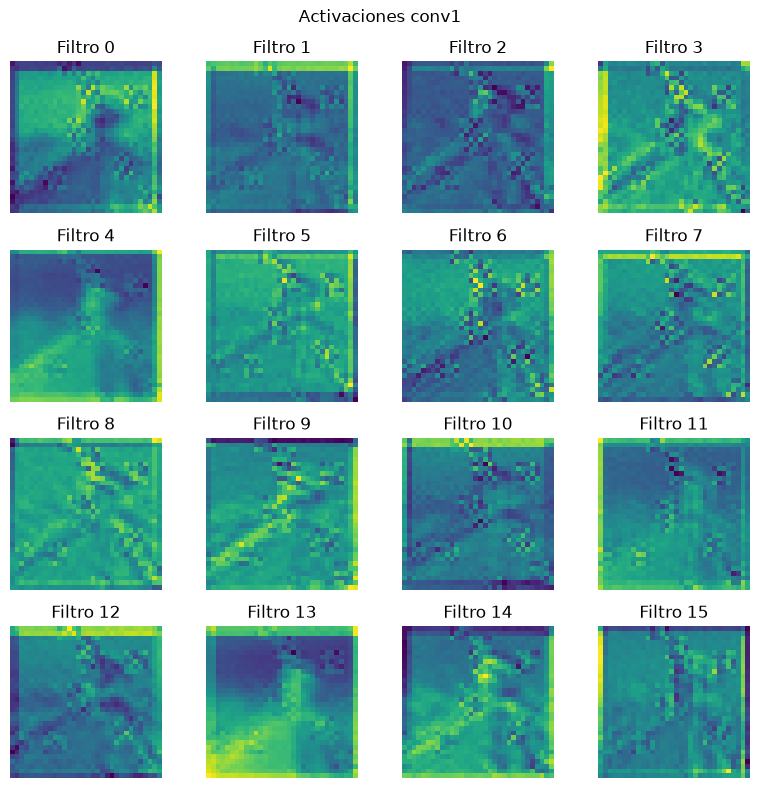

In [30]:
act = activations['conv1'][0]

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv1")
plt.tight_layout()
plt.show()

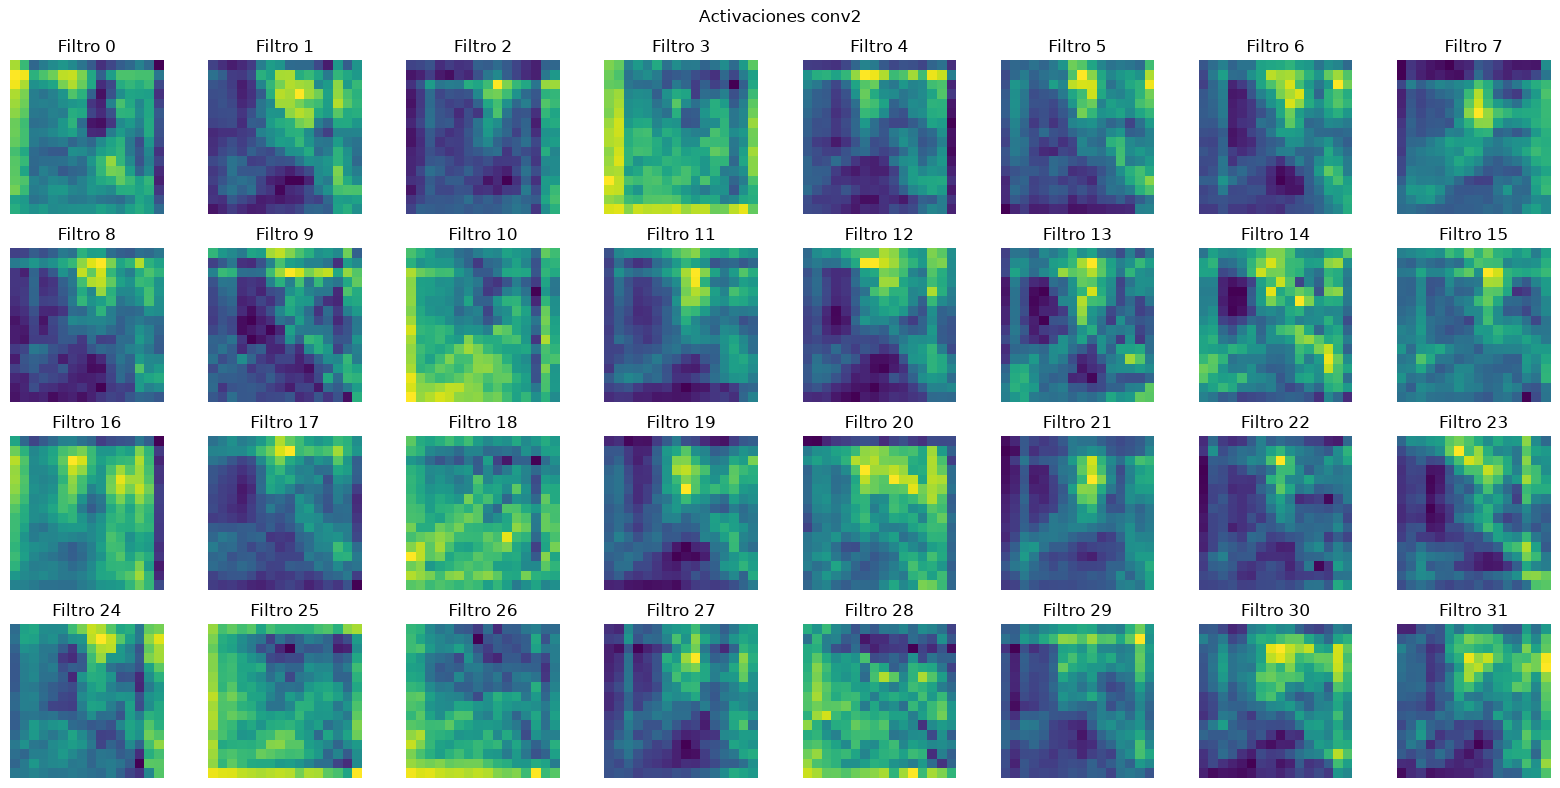

In [31]:
act = activations['conv2'][0]

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(act[i], cmap='viridis')
    ax.set_title(f'Filtro {i}')
    ax.axis('off')

plt.suptitle("Activaciones conv2")
plt.tight_layout()
plt.show()

**Interpretacion**: `conv1` y `conv2` son estructuralmente identicas a las del
notebook gemelo, asi que cualquier diferencia observada aqui no puede atribuirse
a la ausencia de bloque cuantico,
sino a la trayectoria de optimizacion. Esto convierte a esta seccion en un
control: si las activaciones tempranas son similares entre ambos notebooks, el
efecto del bloque final se concentra aguas abajo.

### 4.2. Saliency Maps

In [32]:
saliency = Saliency(model_clf)

image.requires_grad = True
attribution = saliency.attribute(image, target=pred)

# En RGB se agrega el valor absoluto sobre los canales para obtener un mapa 2D,
# que es lo que se compara entre el notebook clasico y el hibrido.
attr = attribution.abs().squeeze(0)
attr = attr.max(dim=0).values if IN_CH > 1 else attr.squeeze(0)
attr = attr.cpu().detach().numpy()

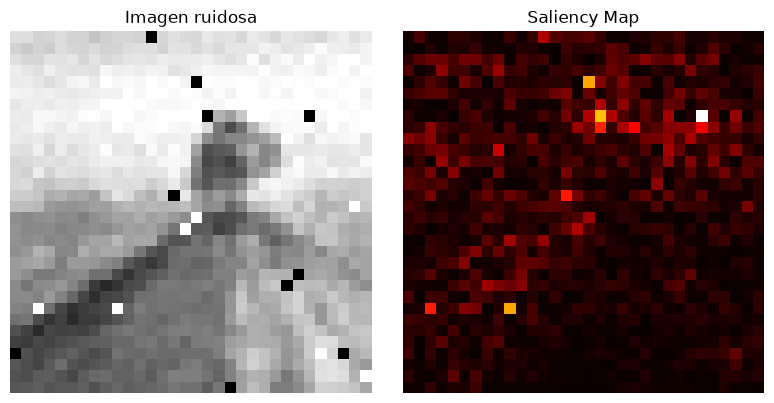

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(to_disp(image), cmap=CMAP)
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(attr, cmap='hot')
axes[1].set_title("Saliency Map")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretacion**: el mapa refleja las regiones cuya perturbacion alteraria mas
la prediccion. Al no haber bloque cuantico, el gradiente recorre unicamente capas clasicas.
En CIFAR-100 conviene fijarse en si la atribucion se distribuye por toda la
imagen (coherente con un ruido que afecta a todos los pixeles) o se concentra en
regiones concretas.

### 4.3. Integrated Gradients

In [34]:
ig = IntegratedGradients(model_clf)

attr_ig = ig.attribute(image, target=pred, n_steps=50).squeeze(0)
attr_ig = attr_ig.sum(dim=0) if IN_CH > 1 else attr_ig.squeeze(0)
attr_ig = attr_ig.cpu().detach().numpy()

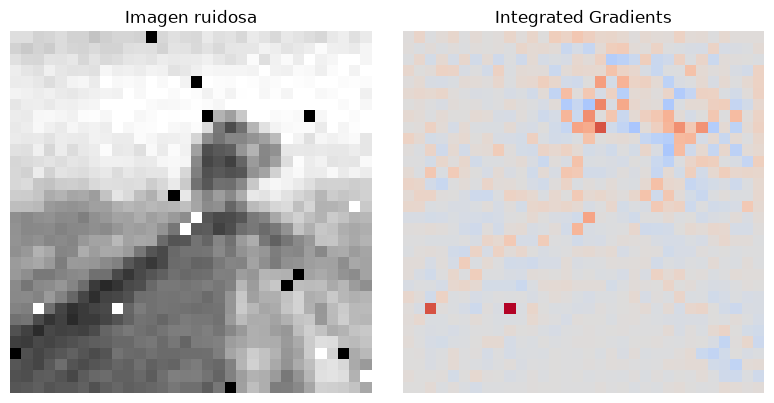

In [35]:
max_val = np.max(np.abs(attr_ig))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(to_disp(image), cmap=CMAP)
axes[0].set_title("Imagen ruidosa")

axes[1].imshow(attr_ig, cmap='coolwarm', vmin=-max_val, vmax=max_val)
axes[1].set_title("Integrated Gradients")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretacion**: Integrated Gradients produce explicaciones mas suaves y
estables que Saliency. Al ser un metodo axiomatico (cumple *completeness* y
*sensitivity*), es uno de los candidatos mas solidos para comparar
cuantitativamente ambas ramas en la memoria.

### 4.4. Grad-CAM

In [36]:
gradcam = LayerGradCam(model_clf, model_clf.conv2)
attr_gc = gradcam.attribute(image, target=pred)

attr_gc_up = LayerAttribution.interpolate(attr_gc, image.shape[2:])
heatmap = attr_gc_up.squeeze().cpu().detach().numpy()

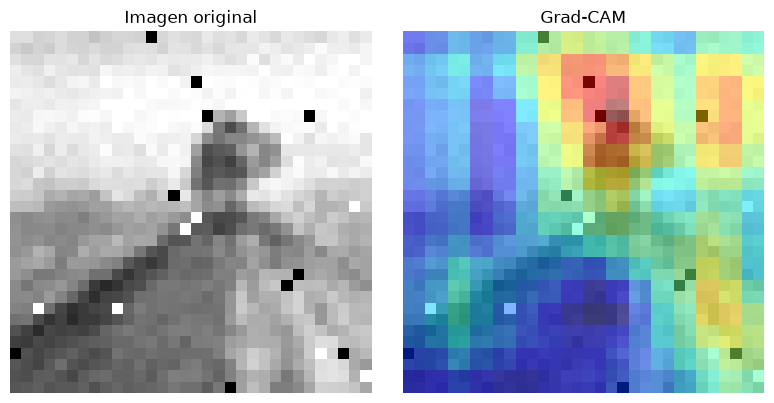

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(to_disp(image), cmap=CMAP)
axes[0].set_title("Imagen original")

axes[1].imshow(to_disp(image), cmap=CMAP)
axes[1].imshow(heatmap, cmap='jet', alpha=0.5)
axes[1].set_title("Grad-CAM")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

**Interpretacion**: Grad-CAM lee de `conv2`, es decir, informacion previa al
bloque final. Es por tanto el metodo menos sensible a la naturaleza de ese
bloque y el punto de comparacion mas estable entre los dos notebooks.

### 4.5. Occlusion Sensitivity

In [38]:
occlusion = Occlusion(model_clf)

# La ventana cubre todos los canales a la vez (IN_CH), de modo que se ocluye la
# region espacial completa y no solo un canal.
attr_occ = occlusion.attribute(
    image,
    strides=(IN_CH, 4, 4),
    target=pred,
    sliding_window_shapes=(IN_CH, 4, 4),
    baselines=0,
)

attr_occ = attr_occ.squeeze(0)
attr_occ = attr_occ.mean(dim=0) if IN_CH > 1 else attr_occ.squeeze(0)
attr_occ = attr_occ.cpu().detach().numpy()

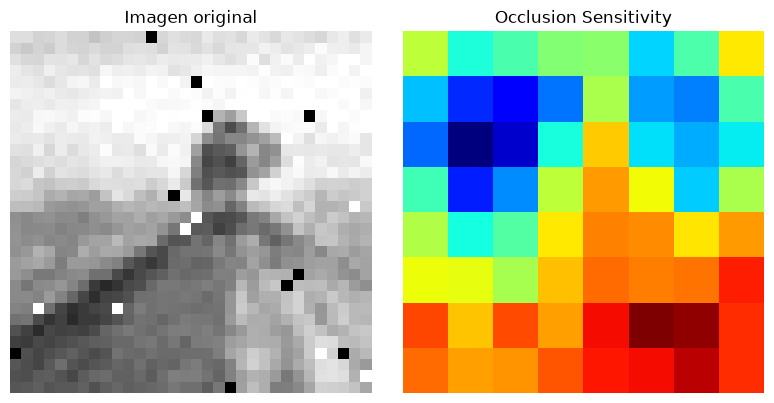

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(to_disp(image), cmap=CMAP)
axes[0].set_title("Imagen original")

axes[1].imshow(attr_occ, cmap='jet')
axes[1].set_title("Occlusion Sensitivity")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Ventana de $4\times4$ y stride $4\times4$ sobre todos los canales: la imagen de
$\mathrm{IMG\_SIZE}\times\mathrm{IMG\_SIZE}$ queda dividida en una rejilla
discreta de bloques.
**Coste computacional**: cada bloque exige una inferencia forward completa; en la rama clasica el coste es moderado.

### 4.6. Espacio latente pre-bloque final (4 dimensiones)

In [40]:
model_clf.eval()

latent_vectors, latent_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        x1 = F.relu(model_clf.conv1(x))
        x1 = model_clf.pool(x1)
        x1 = F.relu(model_clf.conv2(x1))
        x1 = model_clf.pool(x1)
        x1 = x1.reshape(x1.size(0), -1)
        x1 = F.relu(model_clf.fc1(x1))

        latent = torch.tanh(model_clf.fc2(x1)) * np.pi

        latent_vectors.append(latent.cpu().numpy())
        latent_labels.append(y.numpy())

latent_vectors = np.concatenate(latent_vectors)
latent_labels = np.concatenate(latent_labels)
print(latent_vectors.shape)

(100, 4)


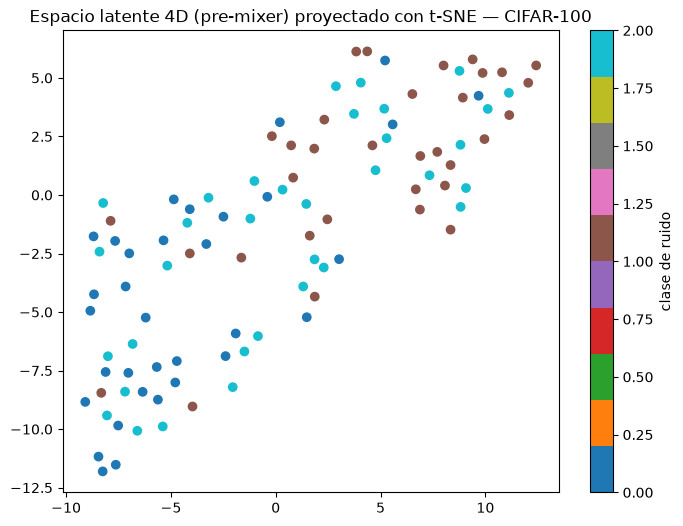

In [41]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=latent_labels, cmap='tab10')
plt.colorbar(scatter, label="clase de ruido")
plt.title("Espacio latente 4D (pre-mixer) proyectado con t-SNE — CIFAR-100")
plt.show()

### 4.7. Analisis de errores

In [42]:
model_clf.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model_clf(x)
        preds = out.argmax(dim=1).cpu()

        wrong = preds != y
        wrong_images.extend(x.cpu()[wrong])
        wrong_preds.extend(preds[wrong])
        wrong_labels.extend(y[wrong])

print(f"Errores de clasificacion: {len(wrong_images)} de {len(test_dataset)}")

Errores de clasificacion: 65 de 100


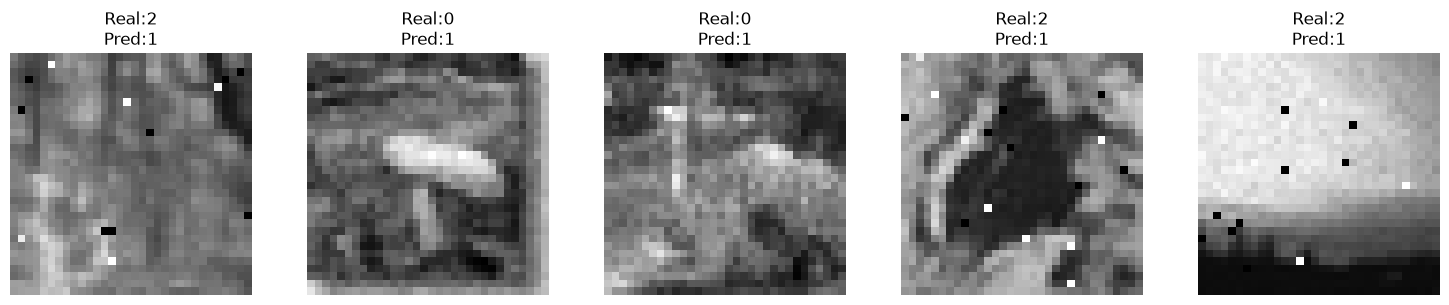

In [43]:
n = min(5, len(wrong_images))

if n == 0:
    print("No se encontraron errores de clasificacion.")
else:
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(to_disp(wrong_images[i]), cmap=CMAP)
        axes[i].set_title(f"Real:{wrong_labels[i]}\nPred:{wrong_preds[i]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

En MNIST, con un test de 100 muestras y un problema muy separable, era habitual
no encontrar errores. En CIFAR-100 es esperable que si aparezcan, lo que hace
esta seccion mas informativa: conviene observar si los fallos se concentran en
alguna clase concreta.

### 4.8. LIME para explicacion local

In [44]:
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic

In [45]:
def predict_lime(images):
    """LIME siempre entrega lotes RGB (N, H, W, 3).

    Si el modelo espera 1 canal se promedian los canales para recuperar la
    escala de grises; si espera 3 se usan tal cual.
    """
    model_clf.eval()

    if IN_CH == 1:
        arr = np.mean(images, axis=-1, keepdims=True).astype(np.float32)
    else:
        arr = images.astype(np.float32)

    tensor = torch.tensor(arr).permute(0, 3, 1, 2).to(device)

    with torch.no_grad():
        outputs = model_clf(tensor)
        probs = torch.softmax(outputs, dim=1)

    return probs.cpu().numpy()

In [46]:
model_clf.eval()

image_test = label_real = label_pred = None

for noisy_img, lbl in test_dataset:
    x = noisy_img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_lime = model_clf(x).argmax(1).item()

    if pred_lime == lbl:
        image_test = noisy_img
        label_real = lbl
        label_pred = pred_lime
        break

print("Instancia elegida | real:", label_real, "| pred:", label_pred)

Instancia elegida | real: 1 | pred: 1


In [47]:
img_np = to_disp(image_test)

# LIME requiere entrada RGB: si la imagen es de 1 canal se replica.
img_rgb = np.stack([img_np] * 3, axis=-1) if img_np.ndim == 2 else img_np

explainer = lime_image.LimeImageExplainer()

segmenter = lambda x: slic(x, n_segments=20, compactness=5, start_label=1)

explanation = explainer.explain_instance(
    img_rgb.astype(np.double),
    predict_lime,
    top_labels=3,
    hide_color=0,
    num_samples=500,
    segmentation_fn=segmenter,
)

100%|██████████| 500/500 [00:00<00:00, 3424.63it/s]


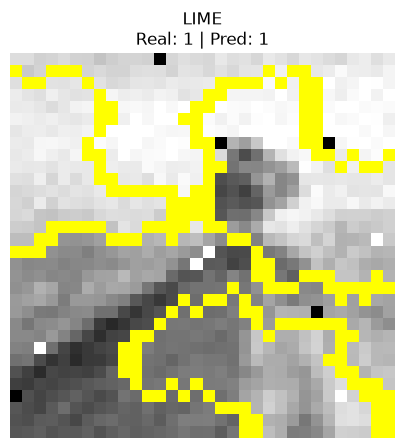

In [48]:
temp, mask = explanation.get_image_and_mask(
    label_pred,
    positive_only=True,
    num_features=5,
    hide_rest=False,
)

plt.figure(figsize=(5, 5))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME\nReal: {label_real} | Pred: {label_pred}")
plt.axis('off')
plt.show()

**Interpretacion**: al ser un metodo de caja negra, LIME no distingue entre las
capas internas del modelo; solo observa la relacion entrada-salida.
**Coste computacional**: las 500 perturbaciones requieren 500 inferencias forward puramente clasicas.

### 4.9. SHAP (GradientExplainer)

In [49]:
import shap

model_clf.eval()

background = []
for i in range(50):
    img, _ = train_dataset[i]
    background.append(img.numpy())
background = np.array(background)

print("background:", background.shape)

background: (50, 1, 32, 32)


In [50]:
image_test_shap, label_real_shap = test_dataset[0]
image_batch = image_test_shap.unsqueeze(0).numpy()

explainer = shap.GradientExplainer(
    model_clf,
    torch.tensor(background, dtype=torch.float32).to(device),
)

shap_values = explainer.shap_values(
    torch.tensor(image_batch, dtype=torch.float32).to(device)
)

print(type(shap_values))
if isinstance(shap_values, list):
    print(len(shap_values), shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(1, 1, 32, 32, 3)


In [51]:
# El formato de salida de shap varia segun la version: puede ser una lista con
# un array por clase, o un unico array con la clase en el ultimo eje.
if isinstance(shap_values, list):
    sv = shap_values[label_real_shap][0]          # (C, H, W)
else:
    sv = shap_values[0, ..., label_real_shap]     # (C, H, W)

sv = np.asarray(sv)
map_shap = sv.sum(axis=0) if sv.ndim == 3 else sv

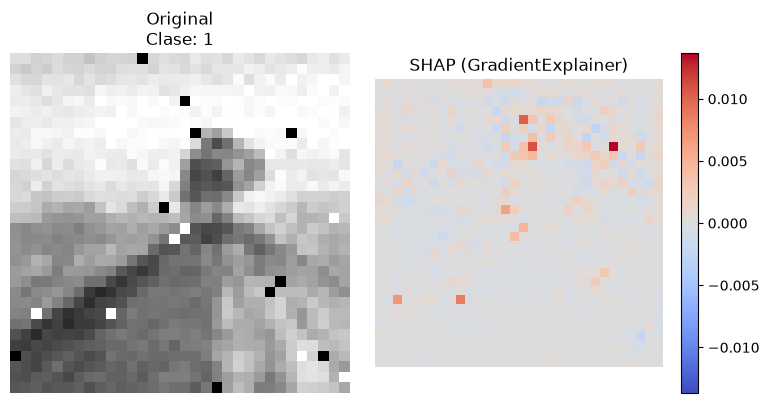

In [52]:
max_val = np.max(np.abs(map_shap))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(to_disp(image_test_shap), cmap=CMAP)
axes[0].set_title(f"Original\nClase: {label_real_shap}")

im = axes[1].imshow(map_shap, cmap='coolwarm', vmin=-max_val, vmax=max_val)
axes[1].set_title("SHAP (GradientExplainer)")

for ax in axes:
    ax.axis('off')

plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

**Interpretacion**: las regiones rojas favorecen la clase predicha y las azules
la penalizan. *Hipotesis a contrastar con `HQ_CNN_CVAE.ipynb`*: cabe esperar que la
CNN clasica produzca mapas de relevancia mas suaves y espacialmente
distribuidos, mientras que la HQNN hibrida podria concentrar la relevancia en
regiones mas discretas como consecuencia de la compresion que impone el paso por
un circuito de solo 4 qubits. Esta hipotesis debe verificarse comparando las
figuras de ambos notebooks, no darse por supuesta.

## 5. Explicabilidad (XAI) del modelo de denoising (ConvVAE)

A diferencia del clasificador, aqui no se explica una clase sino una
reconstruccion: el foco pasa a ser la geometria del espacio latente y el
comportamiento del decoder.

### 5.1. Reconstrucciones y analisis cualitativo

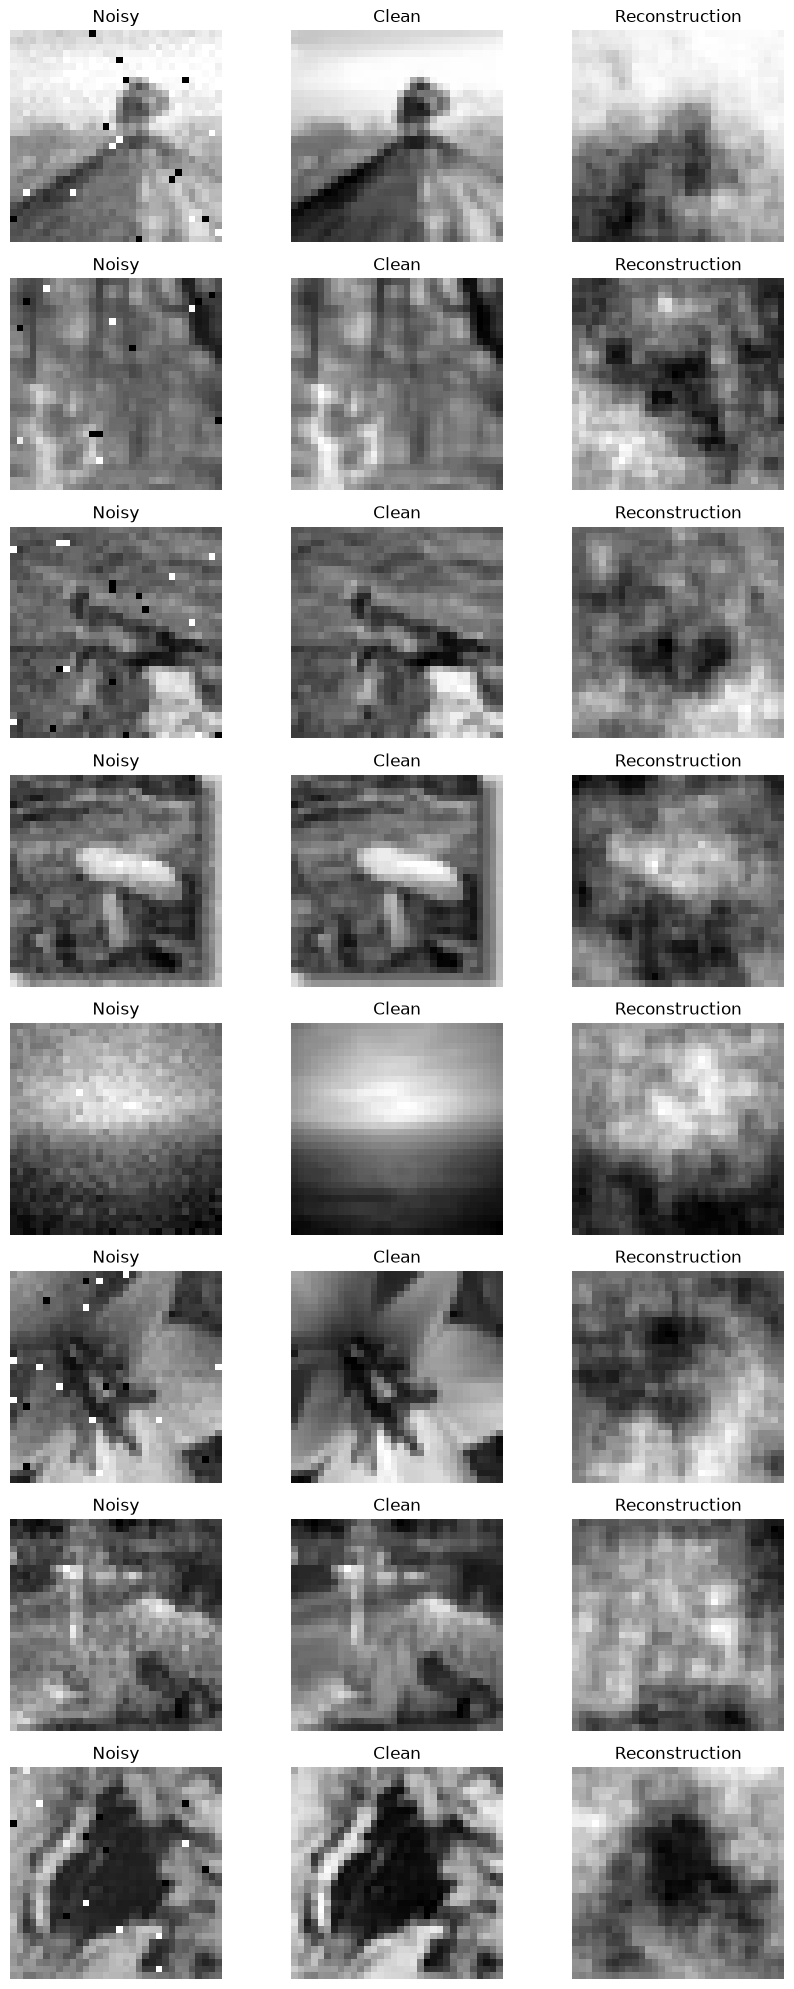

In [53]:
model_vae.eval()

fig, axes = plt.subplots(8, 3, figsize=(9, 20))

with torch.no_grad():
    for i in range(8):
        noisy, clean = test_dataset_dn[i]
        recon, mu, logvar = model_vae(noisy.unsqueeze(0).to(device))

        axes[i, 0].imshow(to_disp(noisy), cmap=CMAP); axes[i, 0].set_title("Noisy")
        axes[i, 1].imshow(to_disp(clean), cmap=CMAP); axes[i, 1].set_title("Clean")
        axes[i, 2].imshow(to_disp(recon), cmap=CMAP); axes[i, 2].set_title("Reconstruction")

        for j in range(3):
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()

**Analisis esperado**: con 15 epocas y 300 muestras de entrenamiento sobre
imagenes naturales, las reconstrucciones seran considerablemente mas borrosas
que en MNIST. Lo relevante para la memoria no es la calidad absoluta sino la
comparacion con el notebook gemelo bajo identico presupuesto.

### 5.2. Organizacion del espacio latente ($\mu$) con PCA

In [54]:
latent_vectors_vae = []

model_vae.eval()
with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy = noisy.to(device)
        mu, logvar = model_vae.encode(noisy)
        latent_vectors_vae.append(mu.cpu())

latent_vectors_vae = torch.cat(latent_vectors_vae).numpy()
print(latent_vectors_vae.shape)

(100, 12)


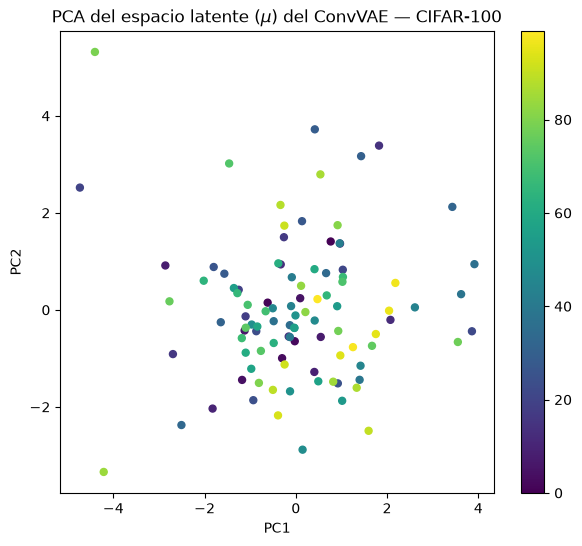

In [55]:
pca = PCA(n_components=2)
latent_2d_vae = pca.fit_transform(latent_vectors_vae)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    latent_2d_vae[:, 0], latent_2d_vae[:, 1],
    c=np.arange(len(latent_2d_vae)), cmap='viridis', s=25,
)
plt.colorbar(scatter)
plt.title("PCA del espacio latente ($\\mu$) del ConvVAE — CIFAR-100")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

**Nota importante**: `mu` es la salida del encoder **clasico** (`fc_mu`), previa
a la transformacion latente.
Por tanto esta proyeccion es directamente comparable entre ambos notebooks: mide
como ha organizado el encoder el espacio latente, no lo que hace el bloque
posterior.

### 5.3. t-SNE del espacio latente

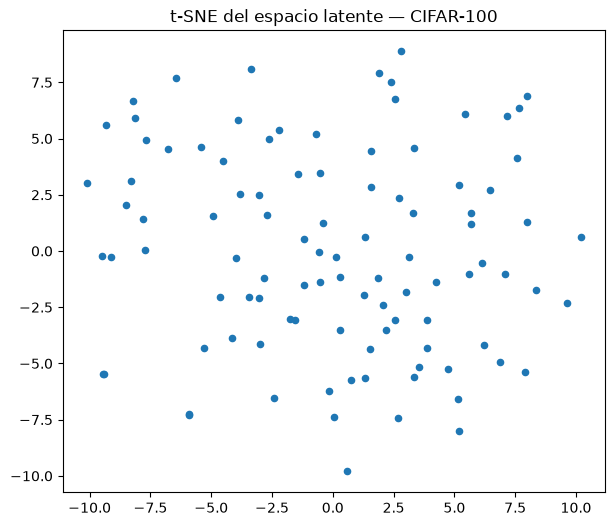

In [56]:
tsne_vae = TSNE(n_components=2, perplexity=15, random_state=42)
latent_tsne = tsne_vae.fit_transform(latent_vectors_vae)

plt.figure(figsize=(7, 6))
plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], s=20)
plt.title("t-SNE del espacio latente — CIFAR-100")
plt.show()

**Interpretacion**: t-SNE revela relaciones no lineales que PCA, al ser una
proyeccion lineal, no puede capturar.

### 5.4. Que regiones afectan mas a la reconstruccion — Saliency del ConvVAE

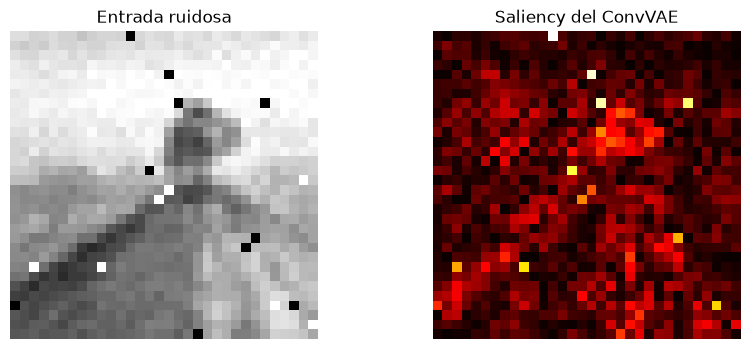

In [57]:
sample_noisy, sample_clean = test_dataset_dn[0]

input_img = sample_noisy.unsqueeze(0).to(device)
input_img.requires_grad = True

recon, _, _ = model_vae(input_img)
loss = F.mse_loss(recon, input_img)
loss.backward()

grad = input_img.grad.abs().squeeze(0)
saliency_vae = (grad.max(dim=0).values if IN_CH > 1 else grad.squeeze(0)).cpu().numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(to_disp(sample_noisy), cmap=CMAP)
plt.title("Entrada ruidosa")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency_vae, cmap='hot')
plt.title("Saliency del ConvVAE")
plt.axis('off')

plt.show()

**Interpretacion**: el gradiente de la perdida de reconstruccion respecto a la
entrada atraviesa unicamente capas clasicas.
En imagenes naturales cabe esperar una atribucion mas repartida que en MNIST,
donde se concentraba en el trazo del digito.

### 5.5. Que partes se pierden — Error residual

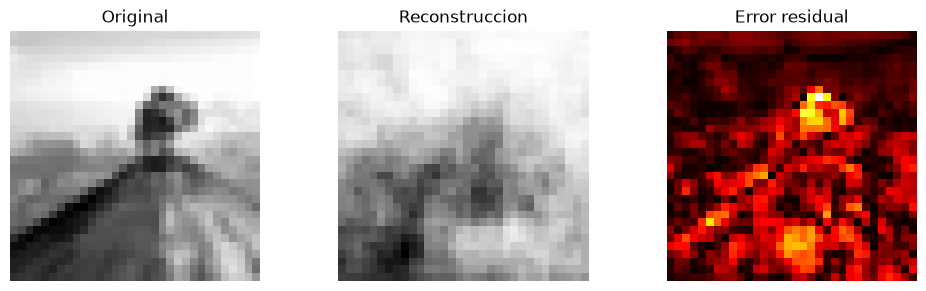

In [58]:
sample_noisy, sample_clean = test_dataset_dn[0]

model_vae.eval()
with torch.no_grad():
    recon, _, _ = model_vae(sample_noisy.unsqueeze(0).to(device))

recon_d = to_disp(recon)
clean_d = to_disp(sample_clean)

error_map = np.abs(clean_d - recon_d)
if error_map.ndim == 3:
    error_map = error_map.mean(axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

axes[0].imshow(clean_d, cmap=CMAP); axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(recon_d, cmap=CMAP); axes[1].set_title("Reconstruccion"); axes[1].axis('off')
axes[2].imshow(error_map, cmap='hot'); axes[2].set_title("Error residual"); axes[2].axis('off')

plt.tight_layout()
plt.show()

**Interpretacion**: el error residual $|x - \hat{x}|$ suele concentrarse en
bordes y texturas de alta frecuencia, que son precisamente las que un latente de
dimension 12 no puede representar.

### 5.6. Que imagina el decoder — Traversals latentes

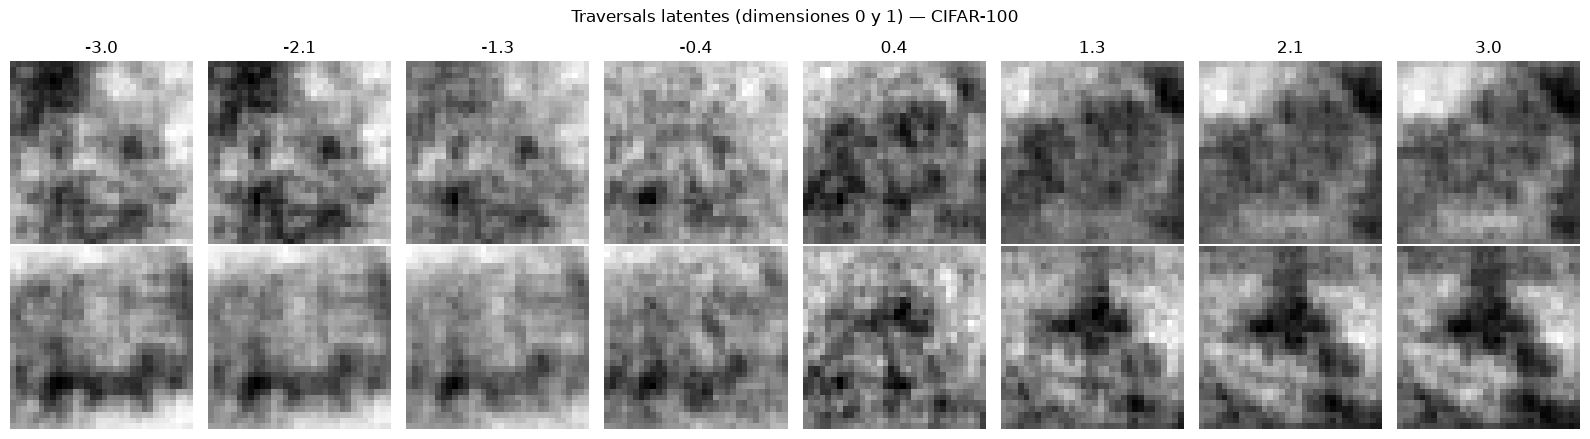

In [59]:
latent_dim = 12

z = torch.zeros((1, latent_dim)).to(device)
values = torch.linspace(-3, 3, steps=8)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))

for dim in range(2):
    for i, val in enumerate(values):
        z_mod = z.clone()
        z_mod[0, dim] = val
        with torch.no_grad():
            recon = model_vae.decode(z_mod)
        axes[dim, i].imshow(to_disp(recon), cmap=CMAP)
        axes[dim, i].axis('off')
        if dim == 0:
            axes[dim, i].set_title(f"{val:.1f}")
    axes[dim, 0].set_ylabel(f"dim {dim}")

plt.suptitle("Traversals latentes (dimensiones 0 y 1) — CIFAR-100")
plt.tight_layout()
plt.show()

**Interpretacion**: al recorrer cada dimension latente manteniendo el resto en 0,
`decode()` muestra que factor de variacion ha capturado esa coordenada.

## 6. Conclusiones y guia de comparacion con el notebook gemelo

Para que la comparacion con `HQ_CNN_CVAE.ipynb` sea util, conviene contrastar
seccion por seccion:

| Seccion | Que comparar |
|---|---|
| 2.3 / 2.4 | Curvas de entrenamiento, accuracy final y matriz de confusion |
| 3.5 / 3.6 | Curvas de perdida y valores de MSE, PSNR y SSIM |
| 4.1 | Activaciones tempranas (control: deberian parecerse) |
| 4.2 - 4.5 | Mapas de atribucion: dispersion, concentracion y coincidencia |
| 4.6  | Separabilidad del espacio latente previo al bloque final |
| 4.5 / 4.8 | Coste computacional relativo de los metodos por perturbacion |
| 5.2 / 5.3 | Geometria del espacio $\mu$ |
| 5.6 | Interpretabilidad de los traversals |

Y, de forma transversal, el contraste con los resultados equivalentes sobre
MNIST: si el modelo hibrido mantiene su ventaja o desventaja relativa al pasar a
imagenes naturales, la conclusion obtenida en MNIST gana solidez; si cambia,
significa que dependia de las particularidades del dataset.

### Exportacion a HTML

In [60]:
import sys
import subprocess
from pathlib import Path

notebook = Path("Classical_CNN_CVAE.ipynb").resolve()
output_dir = notebook.parent

result = subprocess.run(
    [
        sys.executable,
        "-m",
        "nbconvert",
        "--to", "html",
        str(notebook),
        "--output-dir", str(output_dir),
    ],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("\n--- STDOUT ---")
print(result.stdout)
print("\n--- STDERR ---")
print(result.stderr)

if result.returncode == 0:
    print("\nHTML generado correctamente:")
    print(output_dir / "Classical_CNN_CVAE.html")

RETURN CODE: 0

--- STDOUT ---


--- STDERR ---
[NbConvertApp] Converting notebook C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-CIFAR\Classical_CNN_CVAE.ipynb to html
c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\.venv\Lib\site-packages\nbformat\validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 1547053 bytes to C:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\test-CIFAR\Classical_CNN_CVAE.html
